In [1]:
NZ=2396; NX=13601; H=1.25

velmin=1065
velmax=4700

#chosen
fpeak=4

#consequently
h=int(velmin/fpeak/2.5/5)
nz=int(NZ*H/h)+1
nx=int(NX*H/h)+1

print('h,nz,nx=',h,nz,nx)

dt=0.6*h/velmax *0.98
T=5 #time window [s]
nt=int(T/dt)
print('dt,nt=',dt,nt)

dt=0.0026
nt=int(T/dt)
print('adjusted dt,nt=',dt,nt)

ntr=670

h,nz,nx= 21 143 810
dt,nt= 0.0026272340425531914 1903
adjusted dt,nt= 0.0026 1923


In [2]:
import os
import numpy as np
from scipy.signal import hilbert
import matplotlib.pyplot as plt

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def write(filename,data,n=(nx,nz)):
    data.T.astype('float32').tofile(filename)

    
def hilb(data,axis=0):
    return np.imag(hilbert(data,axis=axis))

    
def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/FWD',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"mpirun -np {np} --oversubscribe {app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > $out
        
def run_remote(app='../../exe/FWD',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"mpirun -np {np} --oversubscribe {app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        #!./run.sh
        print("bash ./run.sh")
    else:
        #!./run.sh > $out
        print(f"bash ./run.sh > {out}")

## Prepare

In [3]:
##code
#!(cd ../../ ; git pull ; git checkout teaching ; make prepare)
#!(cd ../../FWD ; make cleanall ; make)
#!(cd ../../FWI ; make cleanall ; make)
#!gfortran smoothgauss2dfast_zhou.f90 -o smoothgauss2dfast_zhou

In [7]:
# #clone model
# # !wget https://s3.amazonaws.com/open.source.geoscience/open_data/elastic-marmousi/elastic-marmousi-model.tar.gz #https://wiki.seg.org/wiki/AGL_Elastic_Marmousi
# # !tar -xvzf elastic-marmousi-model.tar.gz
# # !(cd ./elastic-marmousi-model/model/ ; for fi in `ls *.tar.gz`; do tar -xvzf $$fi; done)
!segyread tape=/home/g202321550/Mycodes/SeisJIMU_VisAC_git_manage/SeisJIMU/Demo/11_Marmousi-runFWI/elastic-marmousi-model/model/MODEL_P-WAVE_VELOCITY_1.25m.segy | sugain bias=0 | sustrip > vp.bin
!segyread tape=/home/g202321550/Mycodes/SeisJIMU_VisAC_git_manage/SeisJIMU/Demo/11_Marmousi-runFWI/elastic-marmousi-model/model/MODEL_DENSITY_1.25m.segy | sustrip | farith op=scale scale=1000 > rho.bin  #convert to [kg/m3]

# !unif2 ninf=1 nz=281 nx=1361 v00=2000 > vp.bin
# !makevel nx=13601 nz=2801 dx=10 dz=10 v000=4000 > vp.bin
# !makevel nx=13601 nz=2801 dx=10 dz=10 v000=1 > rho.bin


segyread: syscalls.c: eopen: open failed (No such file or directory)

sugain: can't get first trace

sustrip: can't get first trace

segyread: syscalls.c: eopen: open failed (No such file or directory)

sustrip: can't get first trace


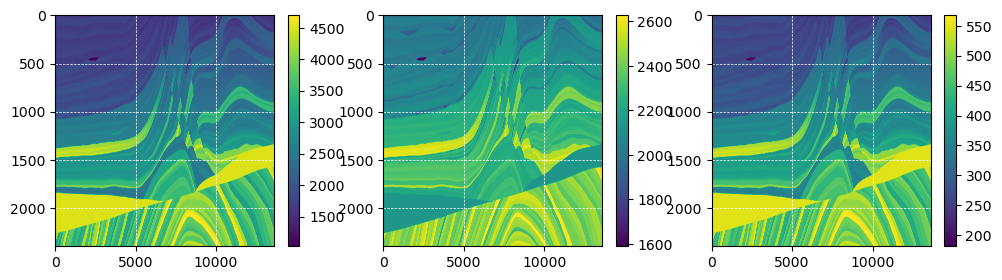

In [26]:
#chop the water layer
vp = read('vp.bin',(13601,2801)) [405:,:]
rho= read('rho.bin',(13601,2801))[405:,:]

#make Qp model by empirical law
#qp = vp**0.5 #leads to a range of ~35--65, small enough to cause instability
qp = vp**0.75 #leads to a range of ~200--550, not yet instability
#qp = vp**0.6 #65-160
# qp = vp**0.55 #40-110

#plot
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(vp)
plt.subplot(1,3,2); imshow(rho)
plt.subplot(1,3,3); imshow(qp)

In [27]:
print(vp.shape)
print(qp.min())
print(qp.max())

(2396, 13601)
181.54941
567.6405


In [28]:
#save to disk
write('vpt.bin',vp)
write('rhot.bin',rho)
write('qpt.bin',qp)

In [29]:
#downsample true models
!make -B true

#make init models
!make -B init

#catenate
str=f'cat vpt.{h}m   rhot.{h}m   qpt.{h}m  > true'
!$str
!cat vpt.init  rhot.init  qpt.init > init

echo 20.1680
20.1680
~/Codes/GitHub/Misc/bin/smoothgauss2dfast_zhou < par
 Input / Output file names (name_in name_out)
 Grid dimensions (n1 n2)
 Grid interval (d1 d2)
 Standard deviation of the Gaussian function (sig1, sig2)
 Wavenumbers (without factor 2*pi) higher than 0.48/sig will be suppressed
 c'est à dire que les nombres d'onde qui sont plus large que 0.48/sig ont l'amplitude sous 1% du crête. 
 Smooth parameter (0) or its inverse (1) or its inverse square (2)
 Constant topography (>=0) or variant (<0)
  go to the square inverse
  grids points involved il2 il1 =           65          65
  go back from the square inverse
   9.28382976E+10
unisam2 < vpt.smth > vpt.21m \
  nx1=2396  dx1=1.25    nx2=13601  dx2=1.25 \
  n1=143    d1=21      n2=810   d2=21
echo 20.1680
20.1680
~/Codes/GitHub/Misc/bin/smoothgauss2dfast_zhou < par
 Input / Output file names (name_in name_out)
 Grid dimensions (n1 n2)
 Grid interval (d1 d2)
 Standard deviation of the Gaussian function (sig1, sig2)
 Wave

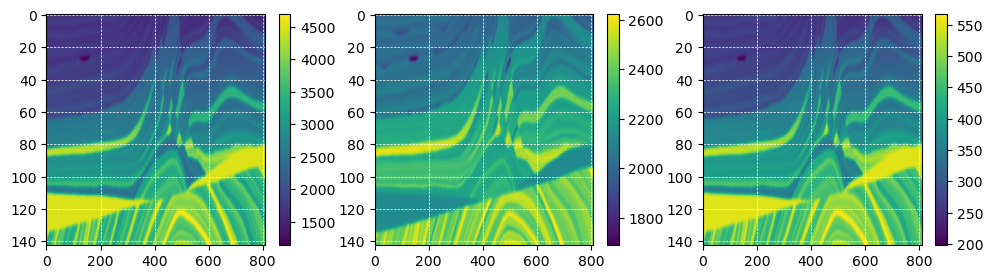

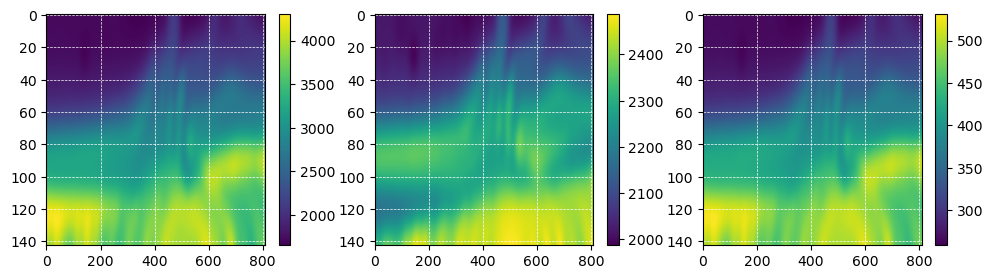

In [30]:
#plot

plt.figure(figsize=(12,3))

true=read('true',(3*nx,nz))
plt.subplot(1,3,1); imshow(true[:,:nx])
plt.subplot(1,3,2); imshow(true[:,nx:2*nx])
plt.subplot(1,3,3); imshow(true[:,2*nx:])

plt.figure(figsize=(12,3))

init=read('init',(3*nx,nz))
plt.subplot(1,3,1); imshow(init[:,:nx])
plt.subplot(1,3,2); imshow(init[:,nx:2*nx])
plt.subplot(1,3,3); imshow(init[:,2*nx:])

In [31]:
#min max of true vp
print(true[:,:nx].min(),true[:,:nx].max())
print(init[:,2*nx:].min())

1142.8925 4691.6123
258.75726


In [32]:
!cat setup_default

MODEL_SIZE              '143 810  1'
MODEL_SPACING           '21  21   1'
FILE_MODEL              'true'
MODEL_ATTRIBUTES        'vp rho qp'
MODEL_ATTRIBUTES_WRITE   vp
#FILE_TOPO              'topo'

IS_FREESURFACE          F

ACQUI_GEOMETRY          spread
FS                      '  0   1200  0'
#DS			'  0   100   0'
#NS			 144
DS			'  0   400  0'
NS			 36
FR                      '  0   0   0'
DR                      '  0   25  0'
NR                       670

SCOMP                   az
RCOMP                   az #p
IF_MUST_USE_RCOMP       T

WAVELET_TYPE	ricker

FPEAK        4
NT           1923
DT           0.0026

IF_SNAPSHOT     T
#NSNAPSHOT    50

#############
## for FWI ##
#############
FILE_DATA_PREFIX    './results_obs/Ru_Shot'
WEIGHTING           'none'

UPDATE_WAVELET	no

PARAMETER           'vp:1065:4700'

SMOOTHING     'none'
#PRECO         'z^0'

JOB             gradient

MAX_ITERATE     120
MAX_MODELING    150


IF_USE_CHECKPOINT   F


## WithOut Freesurface

In [22]:
!cp setup_default setup
!echo "DIR_OUT            results_obs_AC2nd " >> setup

!echo "NS                 1 " >> setup  #Number of Shots
run(app='../../exe/fwd_AC2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_Marmousi
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 738592 Nov  9 17:19 ../../exe/fwd_AC2nd_FDSG_O4_
 Git Commit: b2b4d0f
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/10/2025
System time: 09:07:24
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs_AC2nd
 Output directory:results_obs_AC2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal


In [23]:
!cp setup_default setup
!echo "DIR_OUT            results_obs_VisAC2nd_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "NS                 1 " >> setup  #Number of Shots
run(app='../../exe/fwd_VisAC2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_Marmousi
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 801368 Nov  9 17:42 ../../exe/fwd_VisAC2nd_FDSG_O4_
 Git Commit: b2b4d0f
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/10/2025
System time: 09:07:29
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs_VisAC2nd_noQ
 Output directory:results_obs_VisAC2nd_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *

In [33]:
!cp setup_default setup
!echo "DIR_OUT            results_obs_VisAC2nd " >> setup
!echo "IS_Q_ATTENUATION   T" >> setup
!echo "NS                 1 " >> setup  #Number of Shots
run(app='../../exe/fwd_VisAC2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_Marmousi
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 801368 Nov  9 17:42 ../../exe/fwd_VisAC2nd_FDSG_O4_
 Git Commit: b2b4d0f
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/10/2025
System time: 09:10:35
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs_VisAC2nd
 Output directory:results_obs_VisAC2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_

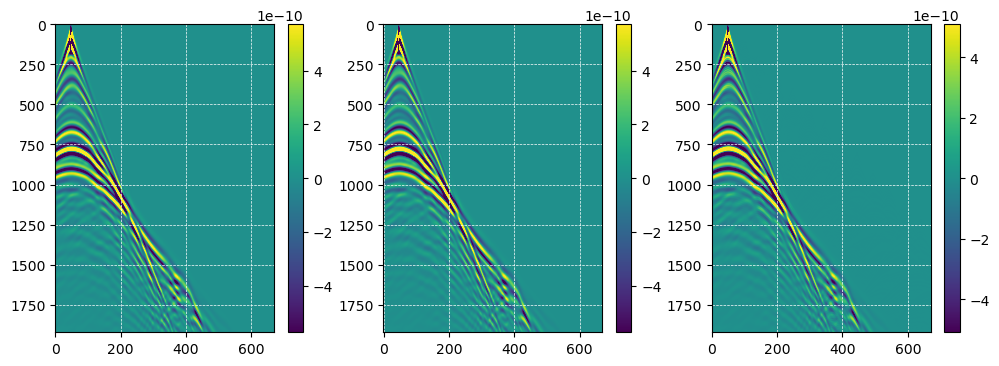

In [34]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results_obs_AC2nd/Ru_Shot0001.su'       ),perc=98)
plt.subplot(1,3,2); imshow(read_su('results_obs_VisAC2nd_noQ/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,3); imshow(read_su('results_obs_VisAC2nd/Ru_Shot0001.su'    ),perc=98)

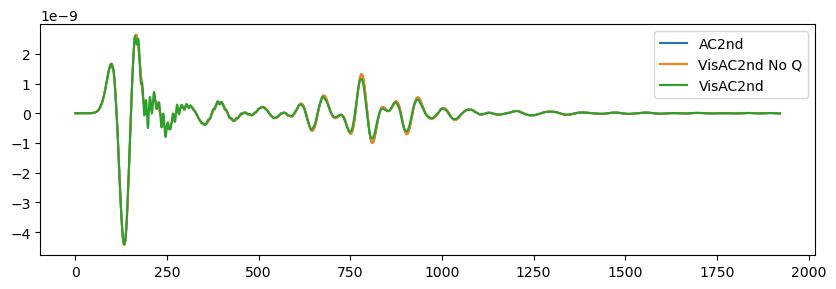

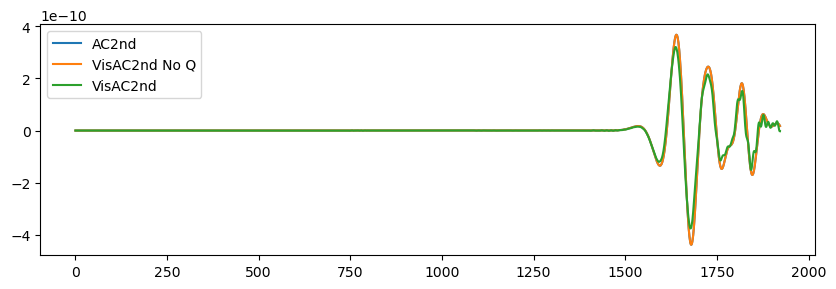

In [36]:
plt.figure(figsize=(10,3))
plt.plot(read_su('results_obs_AC2nd/Ru_Shot0001.su')[:,40])
plt.plot(read_su('results_obs_VisAC2nd_noQ/Ru_Shot0001.su')[:,40])
plt.plot(read_su('results_obs_VisAC2nd/Ru_Shot0001.su')[:,40])
plt.legend(['AC2nd','VisAC2nd No Q','VisAC2nd'])

plt.figure(figsize=(10,3))
plt.plot(read_su('results_obs_AC2nd/Ru_Shot0001.su')[:,400])
plt.plot(read_su('results_obs_VisAC2nd_noQ/Ru_Shot0001.su')[:,400])
plt.plot(read_su('results_obs_VisAC2nd/Ru_Shot0001.su')[:,400])
plt.legend(['AC2nd','VisAC2nd No Q','VisAC2nd'])

## With Freesurface

In [37]:
!cp setup_default setup
!echo "DIR_OUT            results_obs_AC2nd " >> setup

!echo "IS_FREESURFACE     T" >> setup
!echo "NS                 1 " >> setup  #Number of Shots
run(app='../../exe/fwd_AC2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_Marmousi
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 738592 Nov  9 17:19 ../../exe/fwd_AC2nd_FDSG_O4_
 Git Commit: b2b4d0f
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/10/2025
System time: 09:13:42
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs_AC2nd
 Output directory:results_obs_AC2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D ACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal


In [38]:
!cp setup_default setup
!echo "DIR_OUT            results_obs_VisAC2nd_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "IS_FREESURFACE     T" >> setup
!echo "NS                 1 " >> setup  #Number of Shots
run(app='../../exe/fwd_VisAC2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_Marmousi
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 801368 Nov  9 17:42 ../../exe/fwd_VisAC2nd_FDSG_O4_
 Git Commit: b2b4d0f
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/10/2025
System time: 09:13:49
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs_VisAC2nd_noQ
 Output directory:results_obs_VisAC2nd_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *

In [39]:
!cp setup_default setup
!echo "DIR_OUT            results_obs_VisAC2nd " >> setup
!echo "IS_Q_ATTENUATION   T" >> setup
!echo "IS_FREESURFACE     T" >> setup
!echo "NS                 1 " >> setup  #Number of Shots
run(app='../../exe/fwd_VisAC2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/01_ForwardModeling_Marmousi
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 801368 Nov  9 17:42 ../../exe/fwd_VisAC2nd_FDSG_O4_
 Git Commit: b2b4d0f
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/10/2025
System time: 09:14:06
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs_VisAC2nd
 Output directory:results_obs_VisAC2nd/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_

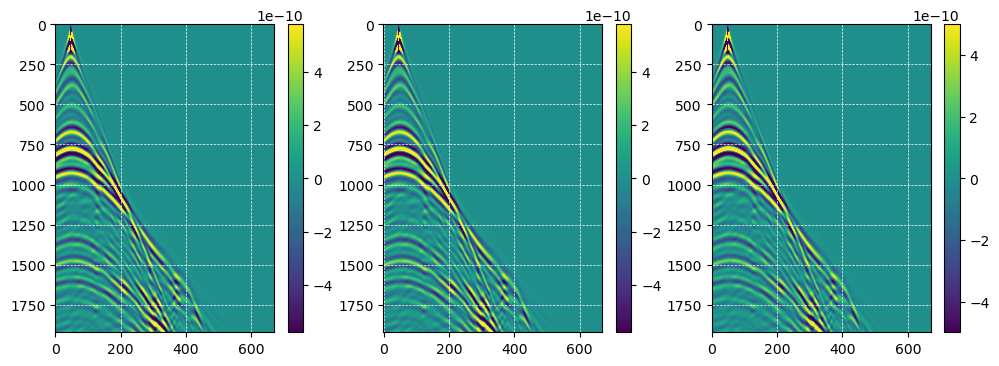

In [40]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results_obs_AC2nd/Ru_Shot0001.su'       ),perc=98)
plt.subplot(1,3,2); imshow(read_su('results_obs_VisAC2nd_noQ/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,3); imshow(read_su('results_obs_VisAC2nd/Ru_Shot0001.su'    ),perc=98)

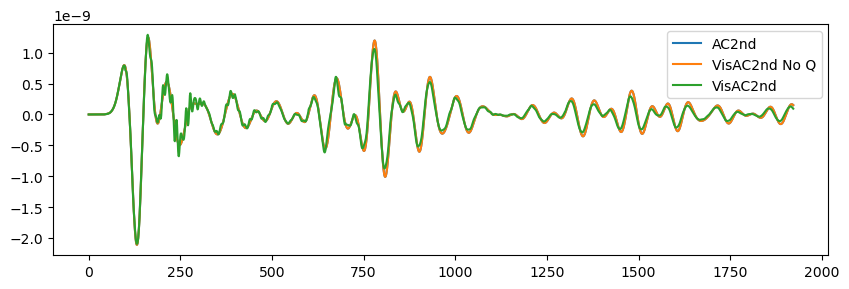

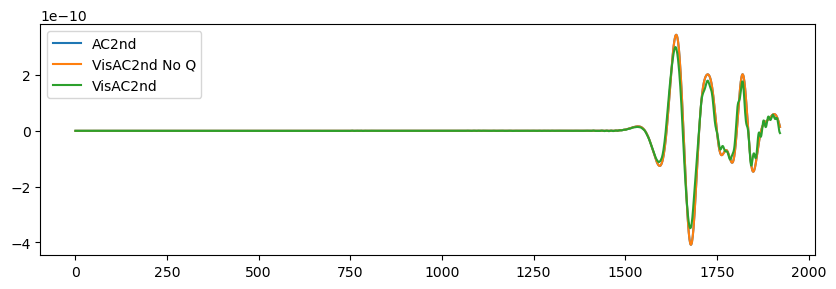

In [41]:
plt.figure(figsize=(10,3))
plt.plot(read_su('results_obs_AC2nd/Ru_Shot0001.su')[:,40])
plt.plot(read_su('results_obs_VisAC2nd_noQ/Ru_Shot0001.su')[:,40])
plt.plot(read_su('results_obs_VisAC2nd/Ru_Shot0001.su')[:,40])
plt.legend(['AC2nd','VisAC2nd No Q','VisAC2nd'])

plt.figure(figsize=(10,3))
plt.plot(read_su('results_obs_AC2nd/Ru_Shot0001.su')[:,400])
plt.plot(read_su('results_obs_VisAC2nd_noQ/Ru_Shot0001.su')[:,400])
plt.plot(read_su('results_obs_VisAC2nd/Ru_Shot0001.su')[:,400])
plt.legend(['AC2nd','VisAC2nd No Q','VisAC2nd'])